# PD Application Scorecard — walkthrough

Every decision in this project, with the real numbers behind it.

**The question:** using only what a lender knows on the day someone applies,
what is the chance they default within 12 months?

Run the cells top to bottom. Everything loads from small saved files, so it
takes seconds, not minutes.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# find the project root, wherever this notebook is opened from
ROOT = Path.cwd()
while not (ROOT / "src" / "config.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import config as cfg
from glossary import MEANING

INTERIM = ROOT / "data" / "interim"
print("project root:", ROOT)
print("cohort:", cfg.COHORT_START, "to", cfg.COHORT_END)

project root: /Users/layaunglinnlett/Documents/Moon/Portfolio/pd-model-application-scorecard
cohort: 2015-01 to 2016-12


---
## 1. The raw data, and why 2015–2016

The Lending Club file holds **2.26 million** loans from 2007 to 2018.
We keep only 2015 and 2016.

Why: the data was photographed in **April 2019**. A loan issued in Dec 2016
has therefore been watched for over two years — long enough for its first
12 months to have fully played out. Nothing is cut short.

loans in our cohort: 855,502
issued between      : Jan 2015 and Dec 2016
data photographed   : Apr 2019


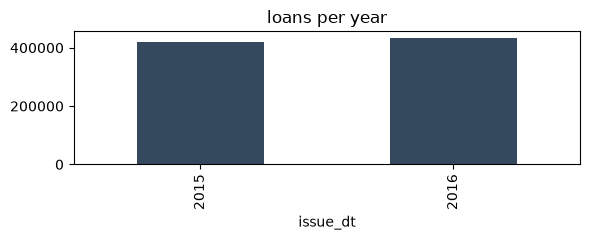

In [2]:
demo = pd.read_parquet(INTERIM / "notebook_demo.parquet")
demo["issue_dt"] = pd.to_datetime(demo["issue_d"], format="%b-%Y")

print(f"loans in our cohort: {len(demo):,}")
print(f"issued between      : {demo.issue_dt.min():%b %Y} and {demo.issue_dt.max():%b %Y}")
print(f"data photographed   : {pd.to_datetime(demo.last_credit_pull_d, format='%b-%Y').max():%b %Y}")

demo.issue_dt.dt.year.value_counts().sort_index().plot(
    kind="bar", figsize=(6, 2.5), color="#34495e", title="loans per year")
plt.tight_layout(); plt.show()

---
## 2. Building the target

The data never says *"this borrower went 90 days late in month 7"*. It only
gives one status per loan, as at April 2019.

So we reconstruct it from two things we DO have — whether the loan died, and
when they last paid:

```
default_within_12_months = 1   if  loan_status is "Charged Off" or "Default"
                               AND last payment was within 8 months of the start
                                   (or they never paid at all)
                         = 0   otherwise
```

Section 3 explains where the **8** comes from.

In [3]:
demo["last_pymnt_dt"] = pd.to_datetime(demo["last_pymnt_d"], format="%b-%Y", errors="coerce")
demo["months_to_last_pymnt"] = (
    (demo.last_pymnt_dt.dt.year - demo.issue_dt.dt.year) * 12
    + (demo.last_pymnt_dt.dt.month - demo.issue_dt.dt.month)
)

died = demo.loan_status.isin(["Charged Off", "Default"])
within = demo.months_to_last_pymnt.isna() | (demo.months_to_last_pymnt <= 8)
demo["default_within_12_months"] = (died & within).astype(int)

print("what happened to each loan, as at Apr 2019:")
print(demo.loan_status.value_counts().to_string())

what happened to each loan, as at Apr 2019:


loan_status
Fully Paid            524595
Current               177360
Charged Off           144045
Late (31-120 days)      5905
In Grace Period         2405
Late (16-30 days)       1181
Default                   11


In [4]:
# four real loans, one of each kind
show = ["issue_d", "last_pymnt_d", "loan_status", "months_to_last_pymnt",
        "default_within_12_months"]

examples = pd.concat([
    demo[died & (demo.months_to_last_pymnt <= 8)].head(1),      # died early  -> 1
    demo[died & (demo.months_to_last_pymnt > 15)].head(1),      # died late   -> 0
    demo[demo.loan_status == "Fully Paid"].head(1),             # repaid      -> 0
    demo[died & demo.months_to_last_pymnt.isna()].head(1),      # never paid  -> 1
])
examples[show]

,issue_d,last_pymnt_d,loan_status,months_to_last_pymnt,default_within_12_months
31,Dec-2015,Jul-2016,Charged Off,7.0,1
13,Dec-2015,May-2017,Charged Off,17.0,0
0,Dec-2015,Jan-2019,Fully Paid,37.0,0
4671,Dec-2015,NaN,Charged Off,NaN,1


In [5]:
n = len(demo)
k = demo.default_within_12_months.sum()
print(f"defaulted within 12 months : {k:,}  ({k/n:.2%})   <-- THE TARGET")
print(f"did not                    : {n-k:,}  ({1-k/n:.2%})")
print(f"\nfor comparison, defaulted at ANY point in the loan's life: "
      f"{died.sum():,} ({died.mean():.2%})")
print(f"so {1 - k/died.sum():.0%} of all defaults happen AFTER month 12")
print(f"\nimbalance: {(n-k)/k:.1f} non-defaulters for every defaulter")

defaulted within 12 months : 31,629  (3.70%)   <-- THE TARGET
did not                    : 823,873  (96.30%)

for comparison, defaulted at ANY point in the loan's life: 144,056 (16.84%)
so 78% of all defaults happen AFTER month 12

imbalance: 26.0 non-defaulters for every defaulter


---
## 3. Where the "8 months" comes from

We assumed a borrower reaches 90 days late about 3 months after their last
payment, which would make the cutoff 9. Rather than trust that, we measured it.

Some loans were still alive but behind at the snapshot, and their status says
*how far* behind. Counting back to their last payment gives the real
relationship.

In [6]:
snapshot = pd.to_datetime(demo.last_credit_pull_d, format="%b-%Y").max()
demo["months_since_pymnt"] = (
    (snapshot.year - demo.last_pymnt_dt.dt.year) * 12
    + (snapshot.month - demo.last_pymnt_dt.dt.month)
)

ladder = (demo[demo.loan_status.isin(
              ["Current", "In Grace Period", "Late (16-30 days)", "Late (31-120 days)"])]
          .groupby("loan_status")["months_since_pymnt"]
          .agg(loans="size", median="median", upper_quarter=lambda s: s.quantile(.75))
          .reindex(["Current", "In Grace Period", "Late (16-30 days)", "Late (31-120 days)"]))
print("months since last payment, by how late they are:\n")
print(ladder.to_string())
print("\nEach missed monthly payment moves them one step further behind.")
print("Note the first row: even a borrower paying perfectly is ~1 month past")
print("their last payment, because payments are monthly. That is not lateness.")
print("\nSo 90 days late sits at ~4 months since last payment  ->  12 - 4 = 8")

months since last payment, by how late they are:

                     loans  median  upper_quarter
loan_status                                      
Current             177360     1.0            1.0
In Grace Period       2405     1.0            2.0
Late (16-30 days)     1181     2.0            2.0
Late (31-120 days)    5905     3.0            4.0

Each missed monthly payment moves them one step further behind.
Note the first row: even a borrower paying perfectly is ~1 month past
their last payment, because payments are monthly. That is not lateness.

So 90 days late sits at ~4 months since last payment  ->  12 - 4 = 8


In [7]:
# how much does that choice actually matter?
rows = []
for cut in [8, 9, 12]:
    lab = (died & (demo.months_to_last_pymnt.isna() | (demo.months_to_last_pymnt <= cut)))
    rows.append({"cutoff": cut, "implied lag (months)": 12 - cut,
                 "defaults": int(lab.sum()), "default rate": f"{lab.mean():.2%}"})
pd.DataFrame(rows)

,cutoff,implied lag (months),defaults,default rate
0,8,4,31629,3.70%
1,9,3,37430,4.38%
2,12,0,55673,6.51%


Measuring the lag narrowed the answer from *"somewhere between 4.38% and 6.51%"*
to *"3.70%, at worst 4.38%"* — about two thirds less uncertainty.

The 12-month row implies a lag of **zero**: that you would be 90 days late the
instant you miss one payment. The ladder above shows that is false, so it stays
only as an extreme bound.

---
## 4. Which columns are we allowed to use?

**The rule:** would the lender know this on the day of the application?

The raw file has 151 columns. Most fail that test — they record what happened
*after* the money was handed over.

In [8]:
inv = pd.read_csv(ROOT / "outputs" / "column_inventory.csv")
print(inv.groupby(["status", "why"]).size()
        .sort_values(ascending=False).to_string())

status           why                                                                                                                     
KEEP             Credit-bureau fact known when they applied.                                                                                 52
DROP             LEAKAGE: recorded after the loan was granted, so it does not exist when a real applicant applies.                           39
                 Only filled in for joint applications, which are rare here. Almost always empty.                                            16
                 Only collected from Dec 2015. Tells you WHEN the loan was issued, not who the borrower is.                                  14
                 Identifier, free text, constant, or a duplicate of a column we already keep.                                                 9
KEEP             Stated by the borrower on the application form.                                                                              

In [9]:
# the two name-traps worth remembering
inv[inv.column.isin(["fico_range_high", "last_fico_range_high",
                     "chargeoff_within_12_mths", "installment",
                     "zip_code", "all_util"])][
    ["column", "meaning", "status", "pct_blank"]].reset_index(drop=True)

,column,meaning,status,pct_blank
0,fico_range_high,Upper end of their credit score band when they...,KEEP,0.00
1,chargeoff_within_12_mths,Write-offs on their OTHER accounts in the last...,KEEP,0.00
2,all_util,% of all their credit limits used,DROP,46.73
3,installment,The fixed monthly payment,DROP,0.00
4,zip_code,First three digits of their postcode,DROP,0.00
5,last_fico_range_high,"Most recent credit score, upper end - updated ...",DROP,0.00


Three lessons in that table:

* **`fico_range_high` is safe, `last_fico_range_high` leaks.** Same concept, but
  `last_` means the score kept being refreshed after the loan started.
* **`chargeoff_within_12_mths` sounds like the target and isn't** — it counts
  write-offs on the borrower's *other* accounts, before they applied.
* **`installment` was dropped even though it's known at application.** It is
  calculated from the interest rate, so keeping it would smuggle Lending Club's
  own risk grade back in after we removed it.

A column's name cannot settle this. Only *when the value was written down* can.

---
## 5. Missing data

A blank is not always the same thing, and the difference matters.

In [10]:
train = pd.read_parquet(INTERIM / "train.parquet")
y = train["default_within_12_months"]
X = train.drop(columns=["default_within_12_months"])

miss = X.isna().mean()
miss = miss[miss > 0].sort_values(ascending=False)

out = pd.DataFrame({
    "% blank": (miss * 100).round(1),
    "meaning": [MEANING.get(c, "") for c in miss.index],
    "default rate when BLANK": [f"{y[X[c].isna()].mean():.2%}" for c in miss.index],
    "default rate when FILLED": [f"{y[~X[c].isna()].mean():.2%}" for c in miss.index],
})
print(f"{X.shape[1]} features kept; {len(miss)} have blanks "
      f"({X.shape[1]-len(miss)} are completely full)\n")
out

61 features kept; 16 have blanks (45 are completely full)



,% blank,meaning,default rate when BLANK,default rate when FILLED
mths_since_last_record,81.6,Months since their last public record (blank =...,3.58%,4.21%
mths_since_recent_bc_dlq,74.3,Months since last late on a credit card (blank...,3.70%,3.68%
mths_since_last_major_derog,70.9,"Months since a serious black mark, 90+ days la...",3.64%,3.84%
mths_since_recent_revol_delinq,63.8,Months since last late on a credit card or lin...,3.74%,3.62%
mths_since_last_delinq,47.8,Months since they were last behind on a paymen...,3.74%,3.66%
mths_since_recent_inq,10.5,Months since a lender last checked their credi...,2.23%,3.87%
emp_length,6.1,"How long they have been employed, 0 to 10+ years",4.92%,3.62%
num_tl_120dpd_2m,4.8,Accounts 120+ days late in the last 2 months,4.33%,3.67%
bc_util,1.1,% of their credit card limits used,4.29%,3.69%
percent_bc_gt_75,1.0,% of their credit cards charged above 75% of t...,4.32%,3.69%


Read the last two columns. For `mths_since_recent_inq`, borrowers with a **blank**
default *less* often (2.23% vs 3.87%) — the blank means "no lender has checked
their credit recently", which is good news. For `emp_length` it goes the other
way: people who don't state their employment default **more** (4.92% vs 3.62%).

Either way, the blank carries information. So we record it as a flag rather than
quietly filling it in and losing it.

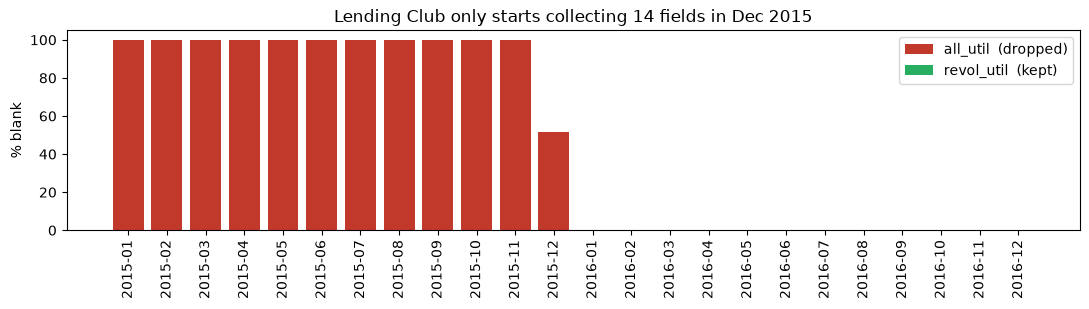

         all_util  revol_util
month                        
2015-10     100.0         0.0
2015-11     100.0         0.0
2015-12      51.8         0.0
2016-01       0.2         0.1
2016-02       0.0         0.0


In [11]:
# the one kind of blank we could NOT fix: 14 columns that are really a date stamp
demo["month"] = demo.issue_dt.dt.to_period("M").astype(str)
cliff = demo.groupby("month")[["all_util", "revol_util"]].apply(lambda g: g.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(cliff.index, cliff.all_util, color="#c0392b", label="all_util  (dropped)")
ax.bar(cliff.index, cliff.revol_util, color="#27ae60", label="revol_util  (kept)")
ax.set_ylabel("% blank"); ax.set_ylim(0, 105); ax.legend()
ax.set_title("Lending Club only starts collecting 14 fields in Dec 2015")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

print(cliff.loc[["2015-10", "2015-11", "2015-12", "2016-01", "2016-02"]].round(1).to_string())

Those 14 columns are missing for ~100% of 2015 loans and ~0% of 2016 loans. So
their presence tells you **when the loan was issued**, not who the borrower is.

A model given them would learn *"loans issued before December 2015 are safer"* —
true of this file, useless for a new applicant. They were dropped rather than
filled.

---
## 6. Splitting the data

Three piles: one to learn from, one to tune on, and one sealed until the very
end. `stratify` forces the same default rate into each.

In [12]:
piles = {name: pd.read_parquet(INTERIM / f"{name}.parquet")
         for name in ["train", "val", "test"]}

pd.DataFrame([{
    "pile": name,
    "rows": f"{len(d):,}",
    "defaults": f"{int(d.default_within_12_months.sum()):,}",
    "default rate": f"{d.default_within_12_months.mean():.4%}",
} for name, d in piles.items()])

,pile,rows,defaults,default rate
0,train,"513,300","18,977",3.6971%
1,val,"171,101","6,326",3.6972%
2,test,"171,101","6,326",3.6972%


Look at the last two columns together. The **counts** differ enormously
(18,977 vs 6,326) but the **rates** match to four decimal places.

That is what `stratify` does: it splits the defaulters *and* the non-defaulters
in the same proportion, so both halves of the fraction shrink together.

---
## 7. The baseline model

Plain logistic regression — no class weighting, no resampling. It is a points
system: every feature gets a weight, you add up a borrower's points, and convert
the total into a probability.

In [13]:
import joblib
pipe = joblib.load(ROOT / "outputs" / "models" / "baseline_logistic.joblib")

def add_flags(df):
    df = df.copy()
    for col in cfg.MISSING_FLAG_COLUMNS:
        df[f"{col}_missing"] = df[col].isna().astype("int8")
    return df

cat = cfg.CATEGORICAL_FEATURES
flags = [f"{c}_missing" for c in cfg.MISSING_FLAG_COLUMNS]
num = [c for c in cfg.model_features() if c not in cat]

val = add_flags(piles["val"])
X_val, y_val = val[num + flags + cat], val["default_within_12_months"]
p = pipe.predict_proba(X_val)[:, 1]

print(f"borrowers scored          : {len(p):,}")
print(f"actually defaulted        : {int(y_val.sum()):,}")
print(f"model flags (prob >= 50%) : {(p >= 0.5).sum()}   <-- the imbalance problem")

borrowers scored          : 171,101
actually defaulted        : 6,326
model flags (prob >= 50%) : 14   <-- the imbalance problem


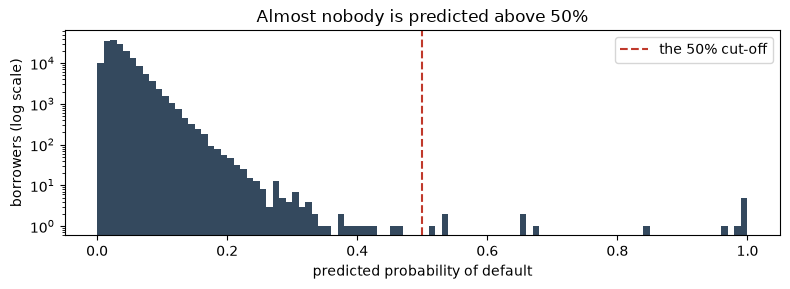

where the predictions actually sit:
   50.0% of borrowers score below 3.05%
   90.0% of borrowers score below 6.90%
   99.0% of borrowers score below 12.84%
   99.9% of borrowers score below 20.70%


In [14]:
plt.figure(figsize=(8, 3))
plt.hist(p, bins=100, color="#34495e")
plt.axvline(0.5, color="#c0392b", ls="--", label="the 50% cut-off")
plt.yscale("log"); plt.xlabel("predicted probability of default")
plt.ylabel("borrowers (log scale)"); plt.legend()
plt.title("Almost nobody is predicted above 50%")
plt.tight_layout(); plt.show()

print("where the predictions actually sit:")
for q in [.5, .9, .99, .999]:
    print(f"  {q:>6.1%} of borrowers score below {np.quantile(p, q):.2%}")

The model is not broken — it is being rational. Only 3.7% of borrowers default,
so it is rarely more than 50% sure about anyone. Judging it at a 50% cut-off is
the wrong test, which is why accuracy is useless here and why we will try
`class_weight='balanced'` next.

---
## 8. A problem the model exposed

One borrower was scored at **99.9999%**. Logistic regression should never be
that certain. Chasing it down found bad data.

In [15]:
worst = int(np.argmax(p))
Z = pipe.named_steps["prep"].transform(X_val)
names = [n.split("__", 1)[1] for n in pipe.named_steps["prep"].get_feature_names_out()]

print(f"highest-scored borrower : {p[worst]:.4%} chance of default")
print(f"did they actually default? {'yes' if y_val.iloc[worst] else 'NO'}\n")

row = Z[worst]
top = np.argsort(-np.abs(row))[:4]
print("their most extreme values (in standard deviations from average):\n")
for i in top:
    raw = X_val[names[i]].iloc[worst] if names[i] in X_val.columns else "-"
    print(f"  {names[i]:<24}{row[i]:>8.1f} SDs   actual value: {raw}")

highest-scored borrower : 99.9999% chance of default
did they actually default? NO

their most extreme values (in standard deviations from average):

  dti                        101.1 SDs   actual value: 999.0
  loan_amnt                    2.3 SDs   actual value: 35000.0
  total_acc                   -1.4 SDs   actual value: 8.0
  num_rev_accts               -1.2 SDs   actual value: 5.0


In [16]:
print("dti = debt-to-income %. A normal value is 15-30.\n")
for q in [.5, .99, .999, .9999, 1.0]:
    print(f"  {q:>8.2%} of borrowers below  {train.dti.quantile(q):>7.1f}")
print(f"\n  borrowers with dti >= 100 : {(train.dti >= 100).sum():,} out of {len(train):,}")
print(f"  borrowers with dti == 999 : {(train.dti == 999).sum():,}   <-- a placeholder, not a real value")

z = ((train.select_dtypes('number').drop(columns=['default_within_12_months'])
      .pipe(lambda d: (d - d.mean()) / d.std())).abs().max().sort_values(ascending=False))
print("\ncolumns with the most extreme outliers:")
print(z.head(6).round(1).to_string())

dti = debt-to-income %. A normal value is 15-30.

    50.00% of borrowers below     18.4
    99.00% of borrowers below     38.8
    99.90% of borrowers below     49.1
    99.99% of borrowers below    138.5
   100.00% of borrowers below    999.0

  borrowers with dti >= 100 : 81 out of 513,300
  borrowers with dti == 999 : 5   <-- a placeholder, not a real value



columns with the most extreme outliers:
tot_coll_amt        343.8
total_rev_hi_lim    265.8
delinq_amnt         167.7
tax_liens           135.0
annual_inc          131.0
num_tl_120dpd_2m    124.8


`dti = 999` means debt payments are ten times income — that is a placeholder, not
a borrower. `total_rev_hi_lim = 9,999,999` is another one.

Only 81 rows out of 513,300 have `dti` above 100. But logistic regression
multiplies and adds, so a value 101 standard deviations out swamps everything
else and drags one prediction to near-certainty.

**The fix — still awaiting a decision:** clip every numeric column at its 0.1st
and 99.9th percentile, learned from the training pile only. Standard practice in
credit scoring, where it is called *winsorising*.

---
## Where this leaves us

| | |
|---|---|
| Loans | 855,502 |
| Features, all known at application | 64 |
| Default rate | 3.70% |
| Imbalance | 26 : 1 |
| Baseline ROC-AUC (validation) | 0.697 |

**Next:** cap the outliers, re-fit, walk through the coefficients one by one,
then evaluate properly — confusion matrix, precision, recall, ROC-AUC, KS, Gini.

Nothing has touched the test pile. It stays sealed until the model is final.